# 01- Data Acquisition: Bitcoin Historical Data
## Project: Crypto Market Detection using HMM

this notebook has de goal to download, explore an prepare the par (BTC-USD) historical
price data that will be used to detect market regimes using a hidden Markov model.

**Data source:** Yahoo Finance via *import* 'yfinance' API

### 1.1 Data Download

Daily OHLCV from 2018 to present

In [40]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ta

# Visual Configuration
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14,6)

# Data from history of bitcoin price
btc = yf.download('BTC-USD',start='2018-01-01')
btc.to_csv('../data/raw/btc_usd_raw.csv')

# Data Recolected: OHLCV
print("Dimensions: ",btc.shape)
print("\nColumns: ", btc.columns.tolist())
btc.head()

[*********************100%***********************]  1 of 1 completed

Dimensions:  (2986, 5)

Columns:  [('Close', 'BTC-USD'), ('High', 'BTC-USD'), ('Low', 'BTC-USD'), ('Open', 'BTC-USD'), ('Volume', 'BTC-USD')]


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072


### 1.2 Initial Exploration

In [41]:
# Dataset Struct
print("Shape: ", btc.shape)
print("\nData types: ")
print(btc.dtypes)
print("\nNull values: ")
print(btc.isnull().sum())
print("\nDescriptive Stadistics:")
btc.describe()


Shape:  (2986, 5)

Data types: 
Price   Ticker 
Close   BTC-USD    float64
High    BTC-USD    float64
Low     BTC-USD    float64
Open    BTC-USD    float64
Volume  BTC-USD      int64
dtype: object

Null values: 
Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64

Descriptive Stadistics:


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,2986.000000,2986.000000,2986.000000,2986.000000,2.986000e+03
mean,38175.715801,38909.792207,37350.471802,38157.826608,3.055125e+10
std,32487.155994,33009.189126,31915.084145,32484.974871,2.208152e+10
min,3236.761719,3275.377930,3191.303467,3236.274658,2.923670e+09
25%,9552.001221,9725.413574,9369.246826,9552.409424,1.545165e+10
50%,28064.893555,28510.822266,27419.980469,28040.284180,2.634987e+10
75%,59117.727539,60621.265625,57805.007812,59114.658203,4.028809e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


**Note:** we can see exactly what we expect.The std shows us enormous volatility of $32,487, demonstrating why it is interesting to apply an HMM.
The median is lower than the mean, which shows a negative bias, with very long periods of time pushing the mean upwards.

### 1.3 Price History Visualization

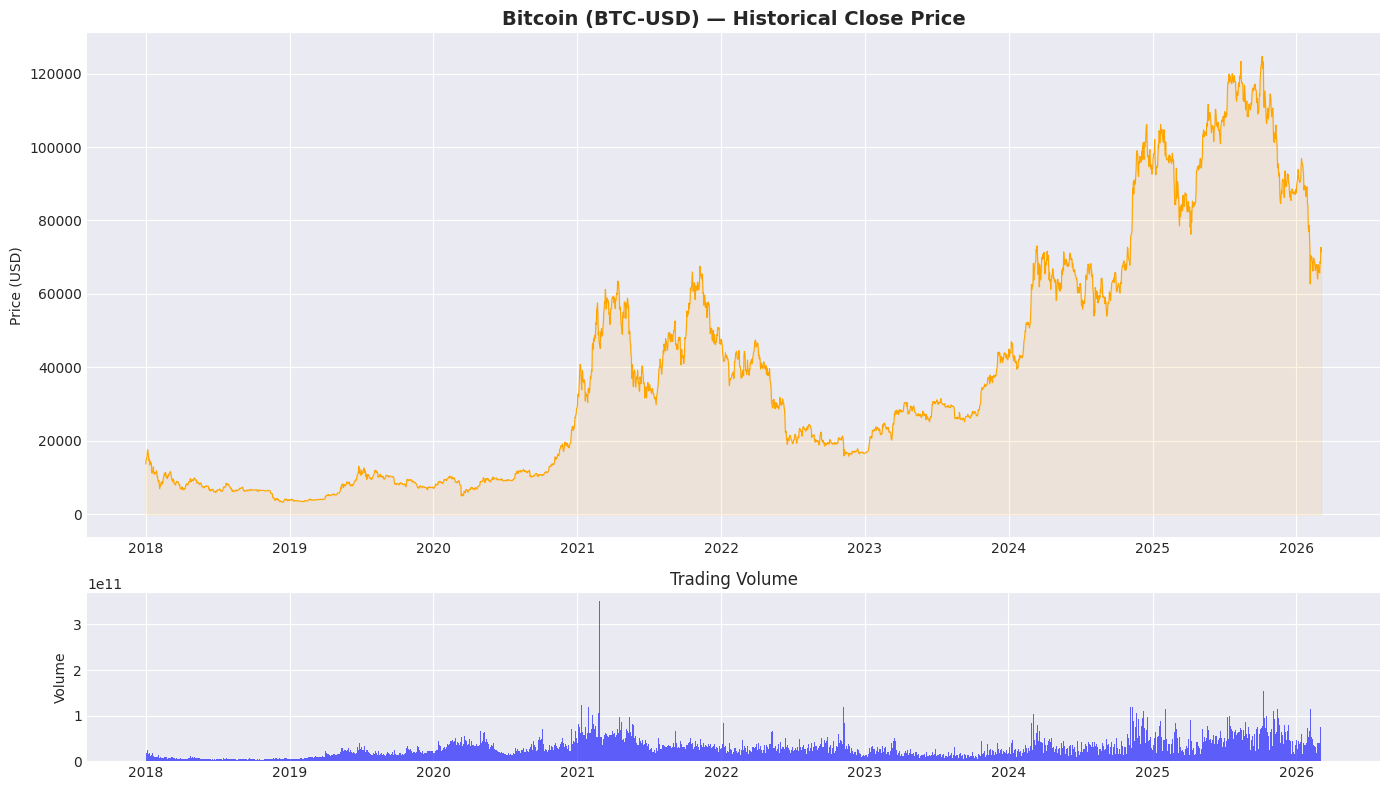

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Precio de cierre
axes[0].plot(btc.index, btc['Close'], color='orange', linewidth=0.8)
axes[0].set_title('Bitcoin (BTC-USD) — Historical Close Price', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].fill_between(btc.index, btc['Close'].values.flatten(), alpha=0.1, color='orange')

# Volumen
axes[1].bar(btc.index, btc['Volume'].values.flatten(), color='blue', alpha=0.6, width=1)
axes[1].set_title('Trading Volume', fontsize=12)
axes[1].set_ylabel('Volume')

plt.tight_layout()
plt.savefig('../results/figures/btc_price_history.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Feature Columns for Analisys- Tecnical Indicators
We need to create features that capture different aspect of market behavior: 
- **Returns:** Log returns (direction of daily movements). Dayly returns symmetric. 
- **Volatility:** Volatility rolling for 7 days and 21 days. The volatility rolling return std over a sliding window of time. We gonna use two 7 days for fast reactions movement, 21 for more soft change and general trend of the price.
- **Momentum:** For the momentum i gonna use Relative Strength Index with his clasical connvencion 14 days.RSI give as the knowledge to sort the range for 0-100 in oversold,neutral,overbought.
- **MACD:** The Moving Average Convergence Divergence measures the difference between fast (12d) and slow (26d) moving averages. The MACD histogram (diff) captures momentum acceleration/deceleration.
- **Volumen** Daily Volumen relative to its 21 days rolling average.
- **Bollinger Band:** Measures the width of Bollinger Bands relative to price

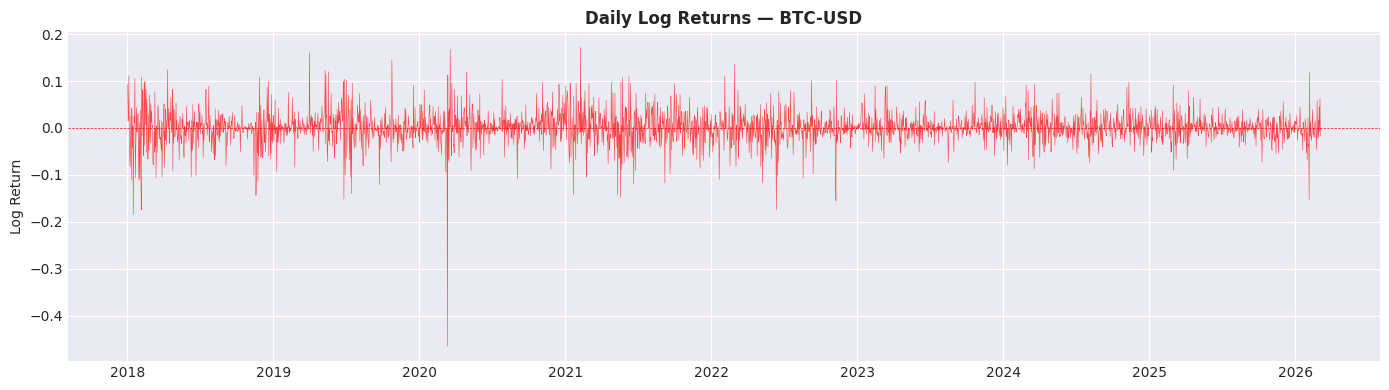


Estadísticas de los retornos:
count    2985.000000
mean        0.000554
std         0.034251
min        -0.464730
25%        -0.013667
50%         0.000631
75%         0.015130
max         0.171821
Name: log_returns, dtype: float64


In [43]:
# Logaritmic Retunrs
btc_use = btc.copy()
btc_use['log_returns'] = np.log(btc_use['Close']/btc_use['Close'].shift(1))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(btc_use.index,btc_use['log_returns'],color='red',linewidth=0.4,alpha=0.7)
ax.axhline(y=0, color='red', linewidth=0.5, linestyle='--')
ax.set_title('Daily Log Returns — BTC-USD', fontsize=12, fontweight='bold')
ax.set_ylabel('Log Return')
plt.tight_layout()
plt.show()

print("\nEstadísticas de los retornos:")
print(btc_use['log_returns'].describe())

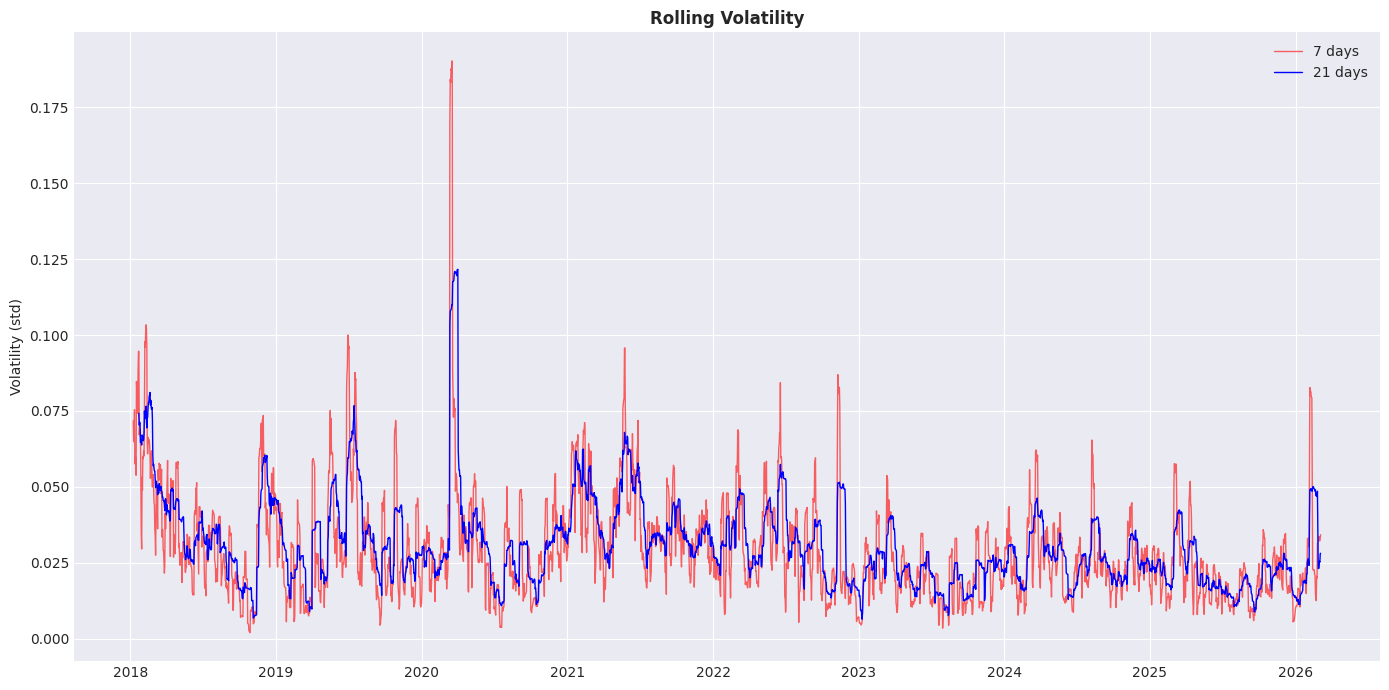

In [44]:
#Volatility Rolling
btc_use['volatility_7d'] = btc_use['log_returns'].rolling(window=7).std()
btc_use['volatility_21d'] = btc_use['log_returns'].rolling(window=21).std()

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(btc_use.index, btc_use['volatility_7d'], color='red', linewidth=1, alpha=0.6, label='7 days')
ax.plot(btc_use.index, btc_use['volatility_21d'], color='blue', linewidth=1, label='21 days')
ax.set_title('Rolling Volatility', fontsize=12, fontweight='bold')
ax.set_ylabel('Volatility (std)')
ax.legend()

plt.tight_layout()
plt.show()

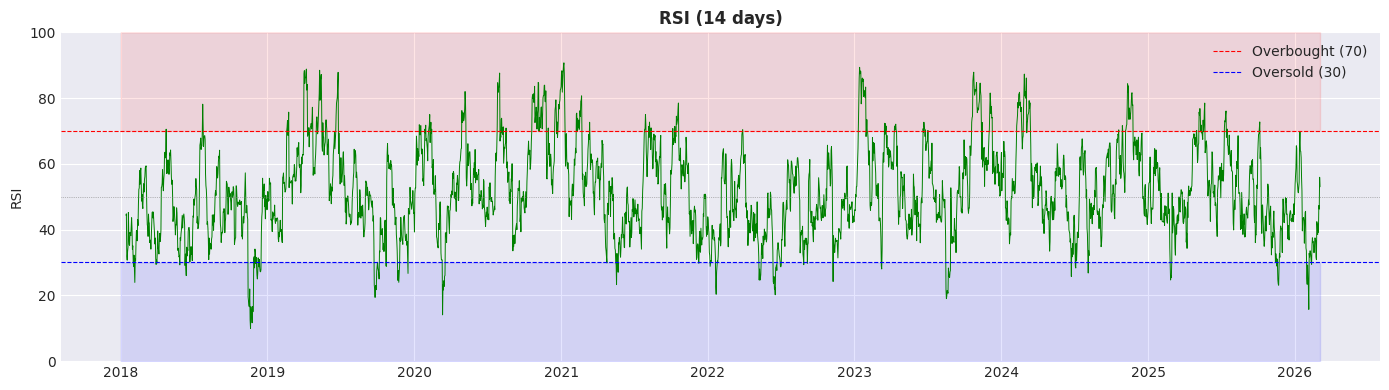

In [45]:
btc_use['rsi']= ta.momentum.RSIIndicator(close=btc_use['Close'].squeeze(),window=14).rsi()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(btc.index, btc_use['rsi'], color='green', linewidth=0.7)
ax.axhline(y=70, color='red', linewidth=0.8, linestyle='--', label='Overbought (70)')
ax.axhline(y=30, color='blue', linewidth=0.8, linestyle='--', label='Oversold (30)')
ax.axhline(y=50, color='gray', linewidth=0.5, linestyle=':')
ax.fill_between(btc_use.index, 70, 100, alpha=0.1, color='red')
ax.fill_between(btc_use.index, 0, 30, alpha=0.1, color='blue')
ax.set_title('RSI (14 days)', fontsize=12, fontweight='bold')
ax.set_ylabel('RSI')
ax.set_ylim(0, 100)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


/tmp/ipykernel_2710/2875263298.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


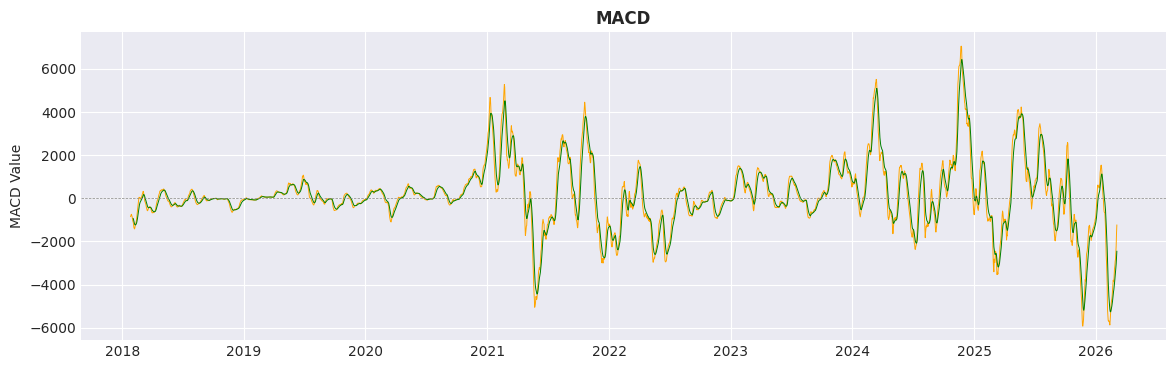

In [52]:
macd = ta.trend.MACD(close=btc_use['Close'].squeeze())
btc_use['macd'] = macd.macd()
btc_use['macd_signal'] = macd.macd_signal()
btc_use['macd_diff'] = macd.macd_diff()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(btc.index, btc_use['macd'], color='orange', linewidth=0.7)
ax.plot(btc.index, btc_use['macd_signal'], color='green', linewidth=0.7)
ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('MACD', fontsize=12, fontweight='bold')
ax.set_ylabel('MACD Value')
ax.legend(loc='upper right')
plt.show()


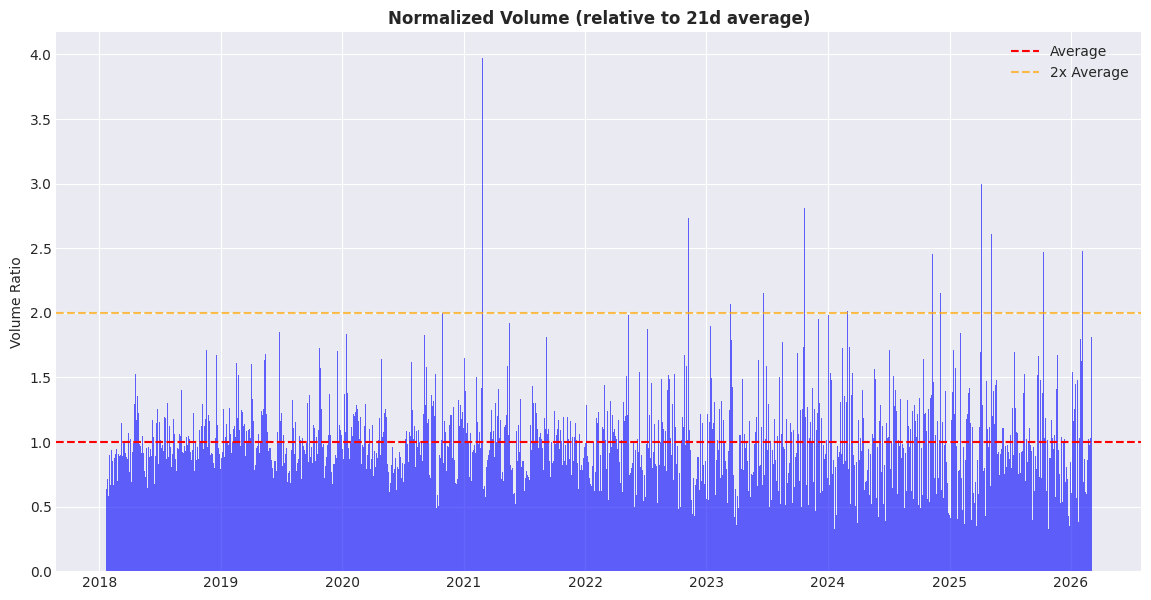

In [64]:
btc_use['volume_norm'] = btc_use['Volume'] / btc_use['Volume'].rolling(window=21).mean()

fig, ax = plt.subplots(figsize=(14,7))
ax.bar(btc_use.index, btc_use['volume_norm'].values.flatten(), color='blue', alpha=0.6, width=1)
ax.axhline(y=1.0, color='red', linewidth=1.5, linestyle='--', label='Average')
ax.axhline(y=2.0, color='orange', linewidth=1.5, linestyle='--', label='2x Average', alpha=0.7)
ax.set_title('Normalized Volume (relative to 21d average)', fontsize=12, fontweight='bold')
ax.set_ylabel('Volume Ratio')
ax.legend()
plt.show()

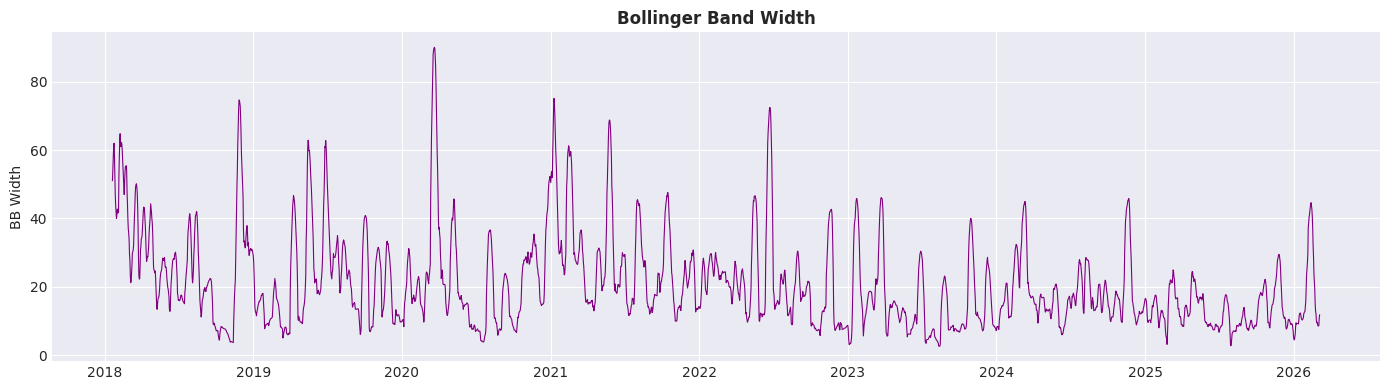

In [65]:
bollinger = ta.volatility.BollingerBands(
    close=btc_use['Close'].squeeze(), 
    window=20
)
btc_use['bb_width'] = bollinger.bollinger_wband()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(btc.index, btc_use['bb_width'], color='purple', linewidth=0.8)
ax.set_title('Bollinger Band Width', fontsize=12, fontweight='bold')
ax.set_ylabel('BB Width')
plt.tight_layout()
plt.show()